## Load Libraries

In [1]:
import torch, torchvision
import matplotlib.pyplot as plt
import json
import cv2
import numpy as np
from copy import deepcopy
from glob import glob
import pandas as pd
import pickle
from sklearn.model_selection import train_test_split
import gc

In [2]:
from transformers import (
    ViltConfig, 
    ViltProcessor, 
    ViltModel, 
    AutoImageProcessor, 
    Data2VecVisionModel, 
    AutoTokenizer, 
    Data2VecTextModel, 
    AutoProcessor,
    FlavaModel
)

## Helpers

In [3]:
def stratified_sample_df(df, col, n_samples):
  sample_train, drop_train = train_test_split(df, train_size=n_samples, stratify=df["label"], shuffle=True, random_state=42)
  return sample_train, drop_train

In [4]:
def process_image(df):
    images = []
    texts = []
    for index, row in df.iterrows():
      img = plt.imread(f'/kaggle/input/ristek-datathon-2022-dataset/media/Image/{row["media"]}')

#       # Detectron expects BGR images
#       img_bgr = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
      images.append(img)

      text = row["text"]
      texts.append(text)
    return images, texts

In [5]:
def clean_ram(var):
    del var; gc.collect()

## Load Dataset

In [6]:
train_df = pd.read_csv(f"/kaggle/input/ristek-datathon-2022-dataset/train.csv")
train_df.head()

,created_at,id,user_id,user_name,url,text,media,label
0,2020-02-23 04:06:39+00:00,1231430140824973313,133931409,r0b1 sur1a (黄玉春),https://twitter.com/R0b1Sur1a/status/123143014...,Akhirnya sampai juga setelah menerobos banjir....,ERbrKgFU4AAnADb.jpg,0
1,2020-01-05 01:46:46+00:00,1213637932411580417,253063316,Beradaptasi di Era Pandemi ☀️,https://twitter.com/MarikaRahman_/status/12136...,"Kemekes RI, IDI Banten, IBI Banten dan PPNI Ba...",ENe1HUVUEAANLFT.jpg,0
2,2020-01-18 06:22:09+00:00,1218418277946396673,64318803,rywyu,https://twitter.com/rywyu/status/1218418277946...,Dikarenakan cikini rada2 banjir tdi pagi hingg...,EOiw80RU0AcJ4CI.jpg,0
3,2020-02-22 23:38:00+00:00,1231362534717837313,17383917,ICALIZERS,https://twitter.com/icalizers/status/123136253...,#sperma TT dikala warga jakarta sedang prihati...,ERatrt9UYAAtLMI.jpg,0
4,2019-12-17 10:54:31+00:00,1206890412574568449,3102973556,AN,https://twitter.com/lokbin103/status/120689041...,"KUIS!\n\nJakarta banjir parah hari ini, pertan...",EL-8Z-vUcAIiIlV.jpg,0


In [7]:
print(f"Before sample shape: {train_df.shape}")
train_df, val_df = stratified_sample_df(train_df, "label", 0.8)
print(f"After sample shape: {train_df.shape}")

Before sample shape: (1518, 8)
After sample shape: (1214, 8)


In [8]:
train_df.label.value_counts()

label
0    953
1    261
Name: count, dtype: int64

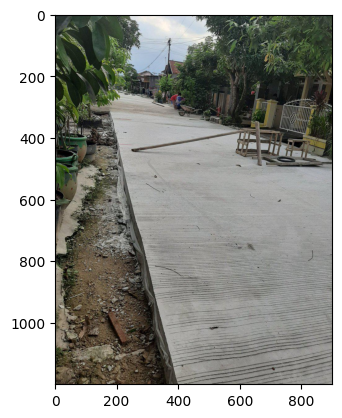

In [14]:
plt.imshow(img)
plt.show()

In [8]:
# config = ViltConfig.from_pretrained("dandelin/vilt-b32-finetuned-vqa")
processor = ViltProcessor.from_pretrained("dandelin/vilt-b32-finetuned-nlvr2")
model = ViltModel.from_pretrained("dandelin/vilt-b32-finetuned-nlvr2")

In [10]:
for i in range(0, len(train_df), 100):
    start = i; end = min(i+100, len(train_df) + 1)
    print("Processing train_df from ", start, "to", end)
    tmp_df = train_df[start:end]
    images, texts = process_image(tmp_df)
    inputs = processor(images, texts, return_tensors="pt", padding="max_length", truncation=True)
    del images; gc.collect()
    del texts; gc.collect()
    
    outputs = model(**inputs)
    del inputs; gc.collect()
    
    last_hidden_states = outputs.last_hidden_state
    del outputs; gc.collect()
    
    with open(f"last_hidden_states_{i}.pkl", "wb") as f:
        pickle.dump(last_hidden_states, f)
    del last_hidden_states; gc.collect()

Processing train_df from  0 to 100
Processing train_df from  100 to 200
Processing train_df from  200 to 300
Processing train_df from  300 to 400
Processing train_df from  400 to 500
Processing train_df from  500 to 600
Processing train_df from  600 to 700
Processing train_df from  700 to 800
Processing train_df from  800 to 900
Processing train_df from  900 to 1000
Processing train_df from  1000 to 1100
Processing train_df from  1100 to 1200
Processing train_df from  1200 to 1215


In [11]:
inputs.keys()

dict_keys(['input_ids', 'token_type_ids', 'attention_mask', 'pixel_values', 'pixel_mask'])

In [ ]:
outputs_1 = model(**inputs_1)

In [ ]:
last_hidden_states = outputs.last_hidden_state

In [ ]:
outputs.keys()

In [11]:
cls_last_outputs = []
for i in range(0, len(train_df), 100):
    print("Loading last hidden states ", i)
    with open(f"last_hidden_states_{i}.pkl", "rb") as f:
        last_hidden_states = pickle.load(f)
        cls_last_outputs += last_hidden_states[:, 0, :]
cls_last_outputs = torch.stack(cls_last_outputs)
cls_last_outputs.shape

Loading last hidden states  0
Loading last hidden states  100
Loading last hidden states  200
Loading last hidden states  300
Loading last hidden states  400
Loading last hidden states  500
Loading last hidden states  600
Loading last hidden states  700
Loading last hidden states  800
Loading last hidden states  900
Loading last hidden states  1000
Loading last hidden states  1100
Loading last hidden states  1200


torch.Size([1214, 768])

In [23]:
len(train_df)

1214

### Train

In [12]:
from catboost import CatBoostClassifier

In [13]:
cb_model = CatBoostClassifier(
    task_type="GPU",
    devices='0',
    verbose=100
)

In [14]:
cb_model.fit(
    cls_last_outputs.detach().numpy(), 
    train_df["label"]
)

Learning rate set to 0.033354
0:	learn: 0.6680518	total: 223ms	remaining: 3m 42s
100:	learn: 0.2140503	total: 5.52s	remaining: 49.1s
200:	learn: 0.1335825	total: 10.8s	remaining: 42.8s
300:	learn: 0.0861691	total: 16s	remaining: 37.2s
400:	learn: 0.0577539	total: 21.3s	remaining: 31.8s
500:	learn: 0.0410170	total: 26.6s	remaining: 26.4s
600:	learn: 0.0299937	total: 31.9s	remaining: 21.1s
700:	learn: 0.0231725	total: 37.1s	remaining: 15.8s
800:	learn: 0.0186202	total: 42.5s	remaining: 10.6s
900:	learn: 0.0154173	total: 47.9s	remaining: 5.26s
999:	learn: 0.0129220	total: 53.2s	remaining: 0us


In [15]:
# save model
with open("cb_model_full2.pkl", "wb") as f:
    pickle.dump(cb_model, f)

In [47]:
# load model
with open("cb_model_full2.pkl", "rb") as f:
    cb_model = pickle.load(f)

### Validation

In [16]:
for i in range(0, len(val_df), 100):
    start = i; end = min(i+100, len(val_df) + 1)
    print("Processing val_df from ", start, "to", end)
    tmp_df = val_df[start:end]
    images, texts = process_image(tmp_df)
    inputs = processor(images, texts, return_tensors="pt", padding="max_length", truncation=True)
    del images; gc.collect()
    del texts; gc.collect()
    
    outputs = model(**inputs)
    del inputs; gc.collect()
    
    last_hidden_states = outputs.last_hidden_state
    del outputs; gc.collect()
    
    with open(f"val_last_hidden_states_{i}.pkl", "wb") as f:
        pickle.dump(last_hidden_states, f)
    del last_hidden_states; gc.collect()

Processing val_df from  0 to 100
Processing val_df from  100 to 200
Processing val_df from  200 to 300
Processing val_df from  300 to 305


In [30]:
val_df.shape

(304, 8)

In [17]:
val_cls_last_outputs = []
for i in range(0, len(val_df), 100):
    print("Loading last hidden states ", i)
    with open(f"val_last_hidden_states_{i}.pkl", "rb") as f:
        last_hidden_states = pickle.load(f)
        val_cls_last_outputs += last_hidden_states[:, 0, :]
val_cls_last_outputs = torch.stack(val_cls_last_outputs)
val_cls_last_outputs.shape

Loading last hidden states  0
Loading last hidden states  100
Loading last hidden states  200
Loading last hidden states  300


torch.Size([304, 768])

In [ ]:
# val_images, val_texts = process_image(val_df)
# val_inputs = processor(val_images, val_texts, return_tensors="pt", padding="max_length", truncation=True)
# val_outputs = model(**val_inputs)
# val_last_hidden_states = val_outputs.last_hidden_state
# val_cls_last_output = val_last_hidden_states[:, 0, :]

In [18]:
val_pred = cb_model.predict(val_cls_last_outputs.detach().numpy())

In [49]:
# import report
from sklearn.metrics import classification_report

print(classification_report(val_df["label"], val_pred))

              precision    recall  f1-score   support

           0       0.86      0.94      0.90       239
           1       0.67      0.43      0.52        65

    accuracy                           0.83       304
   macro avg       0.76      0.69      0.71       304
weighted avg       0.82      0.83      0.82       304



In [33]:
# import report
from sklearn.metrics import classification_report

print(classification_report(val_df["label"], val_pred))

              precision    recall  f1-score   support

           0       0.87      0.95      0.91       239
           1       0.72      0.48      0.57        65

    accuracy                           0.85       304
   macro avg       0.80      0.71      0.74       304
weighted avg       0.84      0.85      0.84       304



### Test

In [34]:
test_df = pd.read_csv(f"/kaggle/input/ristek-datathon-2022-dataset/test.csv")
test_df.head()

,created_at,id,user_id,user_name,url,text,media
0,2020-01-04 04:01:24+00:00,1213309429254250496,3278019654,Dinas LH Cakung,https://twitter.com/DinsihCakung/status/121330...,Giat pengangkutan sampah pasca banjir Rw 02 Ke...,ENaKfJ8VUAIUjb2.jpg
1,2020-01-12 03:14:24+00:00,1216196702647939072,1110443183379382272,Nunung Iskandar,https://twitter.com/IskandarNunung/status/1216...,Giat gotong-royong membersihkan jalan te kena ...,EODMcc8UEAA-7g_.jpg
2,2020-01-12 09:51:05+00:00,1216296533735309312,335900262,🇲🇾.N i e s a a .🇲🇾,https://twitter.com/Cik_AnaaNiesaa/status/1216...,"Terima kasih, tuan hamba. Tetap di sisi hamba ...",EOEnPtTUcAEsJXb.jpg
3,2020-03-02 07:48:31+00:00,1234385081482956800,3278019654,Dinas LH Cakung,https://twitter.com/DinsihCakung/status/123438...,pengambilan toilet portable tuntas pasca banji...,ESFqrKNU8AAip-t.jpg
4,2020-01-08 10:15:55+00:00,1214853229567041537,1186660471580921856,BEM STMIK WIDURI,https://twitter.com/bem_stmikwiduri/status/121...,[PRESS RELEASE]\nPra Kampus Widuri Peduli Benc...,ENwGelmUEAEa6Kq.jpg


In [35]:
test_df.shape

(1011, 7)

In [36]:
for i in range(0, len(test_df), 100):
    start = i; end = min(i+100, len(test_df) + 1)
    print("Processing test_df from ", start, "to", end)
    tmp_df = test_df[start:end]
    images, texts = process_image(tmp_df)
    inputs = processor(images, texts, return_tensors="pt", padding="max_length", truncation=True)
    del images; gc.collect()
    del texts; gc.collect()
    
    outputs = model(**inputs)
    del inputs; gc.collect()
    
    last_hidden_states = outputs.last_hidden_state
    del outputs; gc.collect()
    
    with open(f"test_last_hidden_states_{i}.pkl", "wb") as f:
        pickle.dump(last_hidden_states, f)
    del last_hidden_states; gc.collect()

Processing test_df from  0 to 100
Processing test_df from  100 to 200
Processing test_df from  200 to 300
Processing test_df from  300 to 400
Processing test_df from  400 to 500
Processing test_df from  500 to 600
Processing test_df from  600 to 700
Processing test_df from  700 to 800
Processing test_df from  800 to 900
Processing test_df from  900 to 1000
Processing test_df from  1000 to 1012


In [37]:
test_cls_last_outputs = []
for i in range(0, len(test_df), 100):
    print("Loading last hidden states ", i)
    with open(f"test_last_hidden_states_{i}.pkl", "rb") as f:
        last_hidden_states = pickle.load(f)
        test_cls_last_outputs += last_hidden_states[:, 0, :]
test_cls_last_outputs = torch.stack(test_cls_last_outputs)
test_cls_last_outputs.shape

Loading last hidden states  0
Loading last hidden states  100
Loading last hidden states  200
Loading last hidden states  300
Loading last hidden states  400
Loading last hidden states  500
Loading last hidden states  600
Loading last hidden states  700
Loading last hidden states  800
Loading last hidden states  900
Loading last hidden states  1000


torch.Size([1011, 768])

In [38]:
test_pred = cb_model.predict(test_cls_last_outputs.detach().numpy())
test_pred[:5]

array([0, 0, 0, 0, 0])

In [39]:
sample_submission = pd.read_csv("/kaggle/input/ristek-datathon-2022-dataset/sample_submission.csv")
sample_submission.head()

,id,label
0,1213309429254250496,0
1,1216196702647939072,0
2,1216296533735309312,0
3,1234385081482956800,0
4,1214853229567041537,0


In [40]:
sample_submission["label"] = test_pred
sample_submission.to_csv("submission3.csv", index=False)

## Data2Vec

In [9]:
image_processor = AutoImageProcessor.from_pretrained("facebook/data2vec-vision-base")
image_model = Data2VecVisionModel.from_pretrained("facebook/data2vec-vision-base")

text_processor = AutoTokenizer.from_pretrained("facebook/data2vec-text-base")
text_model = Data2VecTextModel.from_pretrained("facebook/data2vec-text-base")

Some weights of the model checkpoint at facebook/data2vec-text-base were not used when initializing Data2VecTextModel: ['lm_head.bias', 'lm_head.dense.bias', 'lm_head.dense.weight', 'lm_head.layer_norm.bias', 'lm_head.layer_norm.weight']
- This IS expected if you are initializing Data2VecTextModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing Data2VecTextModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of Data2VecTextModel were not initialized from the model checkpoint at facebook/data2vec-text-base and are newly initialized: ['data2vec_text.pooler.dense.bias', 'data2vec_text.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it f

In [11]:
for i in range(0, len(train_df), 100):
    start = i; end = min(i+100, len(train_df) + 1)
    print("Processing train_df from ", start, "to", end)
    tmp_df = train_df[start:end]
    images, _ = process_image(tmp_df)
    image_inputs = image_processor(images, return_tensors="pt")
    del images; gc.collect()
    
    image_outputs = image_model(**image_inputs)
    del image_inputs; gc.collect()
    
    image_last_hidden_states = image_outputs.last_hidden_state[:, 0, :]
    del image_outputs; gc.collect()
    
    with open(f"image_last_hidden_states_{i}.pkl", "wb") as f:
        pickle.dump(image_last_hidden_states, f)
    del image_last_hidden_states; gc.collect()

Processing train_df from  0 to 100


Unused or unrecognized kwargs: padding, truncation.


Processing train_df from  100 to 200


Unused or unrecognized kwargs: padding, truncation.


Processing train_df from  200 to 300


...

Unused or unrecognized kwargs: padding, truncation.


Processing train_df from  1100 to 1200


Unused or unrecognized kwargs: padding, truncation.


Processing train_df from  1200 to 1215


Unused or unrecognized kwargs: padding, truncation.


In [22]:
for i in range(0, len(train_df), 100):
    start = i; end = min(i+100, len(train_df) + 1)
    print("Processing train_df from ", start, "to", end)
    tmp_df = train_df[start:end]
    _, texts = process_image(tmp_df)
    text_inputs = text_processor(texts, return_tensors="pt", padding="max_length", truncation=True, max_length=256)
    del texts; gc.collect()

    text_outputs = text_model(**text_inputs)
    del text_inputs; gc.collect()
    
    text_last_hidden_states = text_outputs.last_hidden_state[:, 0, :]
    del text_outputs; gc.collect()
    
    with open(f"text_last_hidden_states_{i}.pkl", "wb") as f:
        pickle.dump(text_last_hidden_states, f)
    del text_last_hidden_states; gc.collect()

Processing train_df from  0 to 100
Processing train_df from  100 to 200
Processing train_df from  200 to 300
Processing train_df from  300 to 400
Processing train_df from  400 to 500
Processing train_df from  500 to 600
Processing train_df from  600 to 700
Processing train_df from  700 to 800
Processing train_df from  800 to 900
Processing train_df from  900 to 1000
Processing train_df from  1000 to 1100
Processing train_df from  1100 to 1200
Processing train_df from  1200 to 1215


In [10]:
cls_last_outputs = []
for i in range(0, len(train_df), 100):
    print("Loading last hidden states ", i)
    with open(f"image_last_hidden_states_{i}.pkl", "rb") as f:
        image_last_hidden_states = pickle.load(f)
    with open(f"text_last_hidden_states_{i}.pkl", "rb") as f:
        text_last_hidden_states = pickle.load(f)
    concat_last_hidden_states = torch.cat([image_last_hidden_states, text_last_hidden_states], dim=1)
    cls_last_outputs += concat_last_hidden_states
cls_last_outputs = torch.stack(cls_last_outputs)
cls_last_outputs.shape

Loading last hidden states  0
Loading last hidden states  100
Loading last hidden states  200
Loading last hidden states  300
Loading last hidden states  400
Loading last hidden states  500
Loading last hidden states  600
Loading last hidden states  700
Loading last hidden states  800
Loading last hidden states  900
Loading last hidden states  1000
Loading last hidden states  1100
Loading last hidden states  1200


torch.Size([1214, 1536])

In [26]:
from catboost import CatBoostClassifier

cb_model = CatBoostClassifier(
    task_type="GPU",
    devices='0',
    verbose=100
)

In [27]:
cb_model.fit(
    cls_last_outputs.detach().numpy(), 
    train_df["label"]
)

Learning rate set to 0.033354
0:	learn: 0.6669947	total: 273ms	remaining: 4m 33s
100:	learn: 0.2248460	total: 8.64s	remaining: 1m 16s
200:	learn: 0.1475433	total: 16.6s	remaining: 1m 5s
300:	learn: 0.1015238	total: 24.6s	remaining: 57.2s
400:	learn: 0.0705572	total: 32.9s	remaining: 49.1s
500:	learn: 0.0532546	total: 41.1s	remaining: 40.9s
600:	learn: 0.0410796	total: 49.4s	remaining: 32.8s
700:	learn: 0.0326823	total: 57.8s	remaining: 24.7s
800:	learn: 0.0265715	total: 1m 6s	remaining: 16.4s
900:	learn: 0.0221755	total: 1m 14s	remaining: 8.2s
999:	learn: 0.0186010	total: 1m 23s	remaining: 0us


In [28]:
# save model
with open("cb_model_data2vec.pkl", "wb") as f:
    pickle.dump(cb_model, f)

In [10]:
# load model
with open("cb_model_data2vec.pkl", "rb") as f:
    cb_model = pickle.load(f)

In [29]:
for i in range(0, len(val_df), 100):
    start = i; end = min(i+100, len(val_df) + 1)
    print("Processing val_df from ", start, "to", end)
    tmp_df = val_df[start:end]
    images, _ = process_image(tmp_df)
    image_inputs = image_processor(images, return_tensors="pt")
    del images; gc.collect()
    
    image_outputs = image_model(**image_inputs)
    del image_inputs; gc.collect()
    
    image_last_hidden_states = image_outputs.last_hidden_state[:, 0, :]
    del image_outputs; gc.collect()
    
    with open(f"val_image_last_hidden_states_{i}.pkl", "wb") as f:
        pickle.dump(image_last_hidden_states, f)
    del image_last_hidden_states; gc.collect()

Processing val_df from  0 to 100
Processing val_df from  100 to 200
Processing val_df from  200 to 300
Processing val_df from  300 to 305


In [11]:
for i in range(0, len(val_df), 100):
    start = i; end = min(i+100, len(val_df) + 1)
    print("Processing val_df from ", start, "to", end)
    tmp_df = val_df[start:end]
    _, texts = process_image(tmp_df)
    text_inputs = text_processor(texts, return_tensors="pt", padding="max_length", truncation=True, max_length=256)
    del texts; gc.collect()

    text_outputs = text_model(**text_inputs)
    del text_inputs; gc.collect()
    
    text_last_hidden_states = text_outputs.last_hidden_state[:, 0, :]
    del text_outputs; gc.collect()
    
    with open(f"val_text_last_hidden_states_{i}.pkl", "wb") as f:
        pickle.dump(text_last_hidden_states, f)
    del text_last_hidden_states; gc.collect()

Processing val_df from  0 to 100
Processing val_df from  100 to 200
Processing val_df from  200 to 300
Processing val_df from  300 to 305


In [11]:
val_cls_last_outputs = []
for i in range(0, len(val_df), 100):
    print("Loading last hidden states ", i)
    with open(f"val_image_last_hidden_states_{i}.pkl", "rb") as f:
        image_last_hidden_states = pickle.load(f)
    with open(f"val_text_last_hidden_states_{i}.pkl", "rb") as f:
        text_last_hidden_states = pickle.load(f)
    concat_last_hidden_states = torch.cat([image_last_hidden_states, text_last_hidden_states], dim=1)
    val_cls_last_outputs += concat_last_hidden_states
val_cls_last_outputs = torch.stack(val_cls_last_outputs)
val_cls_last_outputs.shape

Loading last hidden states  0
Loading last hidden states  100
Loading last hidden states  200
Loading last hidden states  300


torch.Size([304, 1536])

In [18]:
import lightgbm as lgb

params = {
    "application": "regression",
    "boosting": "gbdt",
    "metric": "rmse",
    "num_leaves": 70,
    "max_depth": 9,
    "learning_rate": 0.01,
    "bagging_fraction": 0.85,
    "feature_fraction": 0.8,
    "min_split_gain": 0.02,
    "min_child_samples": 150,
    "min_child_weight": 0.02,
    "lambda_l2": 0.0475,
    "verbosity": -1,
    "data_random_seed": 17,
}

# Additional parameters:
early_stop = 500
verbose_eval = 100
num_rounds = 10000

d_train = lgb.Dataset(cls_last_outputs.detach().numpy(), label=train_df["label"])
d_valid = lgb.Dataset(val_cls_last_outputs.detach().numpy(), label=val_df["label"])
valid_sets = [d_train, d_valid]

lgbm_model = lgb.train(
    params,
    train_set=d_train,
    num_boost_round=num_rounds,
    valid_sets=valid_sets,
    callbacks=[lgb.early_stopping(stopping_rounds=early_stop), lgb.log_evaluation(verbose_eval)]
)

Training until validation scores don't improve for 500 rounds
[100]	training's rmse: 0.34979	valid_1's rmse: 0.362074
[200]	training's rmse: 0.319308	valid_1's rmse: 0.345154
[300]	training's rmse: 0.299309	valid_1's rmse: 0.340225
[400]	training's rmse: 0.282329	valid_1's rmse: 0.336835
[500]	training's rmse: 0.267967	valid_1's rmse: 0.335739
[600]	training's rmse: 0.255129	valid_1's rmse: 0.334925
[700]	training's rmse: 0.243528	valid_1's rmse: 0.334807
[800]	training's rmse: 0.232986	valid_1's rmse: 0.33423
[900]	training's rmse: 0.223078	valid_1's rmse: 0.333506
[1000]	training's rmse: 0.213826	valid_1's rmse: 0.333721
[1100]	training's rmse: 0.205192	valid_1's rmse: 0.33349
[1200]	training's rmse: 0.19716	valid_1's rmse: 0.333479
[1300]	training's rmse: 0.189524	valid_1's rmse: 0.333653
[1400]	training's rmse: 0.182312	valid_1's rmse: 0.333711
[1500]	training's rmse: 0.175606	valid_1's rmse: 0.333931
[1600]	training's rmse: 0.168972	valid_1's rmse: 0.334047
[1700]	training's rmse:

In [ ]:
val_pred = cb_model.predict(cls_last_outputs.detach().numpy())
val_pred[:5]

In [14]:
# import report
from sklearn.metrics import classification_report

print(classification_report(val_df["label"], val_pred))

              precision    recall  f1-score   support

           0       0.87      0.93      0.90       239
           1       0.67      0.49      0.57        65

    accuracy                           0.84       304
   macro avg       0.77      0.71      0.73       304
weighted avg       0.83      0.84      0.83       304



In [42]:
val_pred = lgbm_model.predict(val_cls_last_outputs.detach().numpy())
val_pred[:5]

array([ 0.47183463,  0.05187577,  0.06372223, -0.01567163, -0.0396808 ])

In [43]:
val_pred = (val_pred > 0.5).astype(int)
val_pred[:5]

array([0, 0, 0, 0, 0])

In [44]:
# import report
from sklearn.metrics import classification_report

print(classification_report(val_df["label"], val_pred))

              precision    recall  f1-score   support

           0       0.87      0.92      0.90       239
           1       0.65      0.51      0.57        65

    accuracy                           0.84       304
   macro avg       0.76      0.72      0.73       304
weighted avg       0.83      0.84      0.83       304



In [45]:
test_df = pd.read_csv(f"/kaggle/input/ristek-datathon-2022-dataset/test.csv")
test_df.head()

,created_at,id,user_id,user_name,url,text,media
0,2020-01-04 04:01:24+00:00,1213309429254250496,3278019654,Dinas LH Cakung,https://twitter.com/DinsihCakung/status/121330...,Giat pengangkutan sampah pasca banjir Rw 02 Ke...,ENaKfJ8VUAIUjb2.jpg
1,2020-01-12 03:14:24+00:00,1216196702647939072,1110443183379382272,Nunung Iskandar,https://twitter.com/IskandarNunung/status/1216...,Giat gotong-royong membersihkan jalan te kena ...,EODMcc8UEAA-7g_.jpg
2,2020-01-12 09:51:05+00:00,1216296533735309312,335900262,🇲🇾.N i e s a a .🇲🇾,https://twitter.com/Cik_AnaaNiesaa/status/1216...,"Terima kasih, tuan hamba. Tetap di sisi hamba ...",EOEnPtTUcAEsJXb.jpg
3,2020-03-02 07:48:31+00:00,1234385081482956800,3278019654,Dinas LH Cakung,https://twitter.com/DinsihCakung/status/123438...,pengambilan toilet portable tuntas pasca banji...,ESFqrKNU8AAip-t.jpg
4,2020-01-08 10:15:55+00:00,1214853229567041537,1186660471580921856,BEM STMIK WIDURI,https://twitter.com/bem_stmikwiduri/status/121...,[PRESS RELEASE]\nPra Kampus Widuri Peduli Benc...,ENwGelmUEAEa6Kq.jpg


In [18]:
for i in range(0, len(test_df), 100):
    start = i; end = min(i+100, len(test_df) + 1)
    print("Processing test_df from ", start, "to", end)
    tmp_df = test_df[start:end]
    images, _ = process_image(tmp_df)
    image_inputs = image_processor(images, return_tensors="pt")
    del images; gc.collect()
    
    image_outputs = image_model(**image_inputs)
    del image_inputs; gc.collect()
    
    image_last_hidden_states = image_outputs.last_hidden_state[:, 0, :]
    del image_outputs; gc.collect()
    
    with open(f"test_image_last_hidden_states_{i}.pkl", "wb") as f:
        pickle.dump(image_last_hidden_states, f)
    del image_last_hidden_states; gc.collect()

Processing test_df from  0 to 100
Processing test_df from  100 to 200
Processing test_df from  200 to 300
Processing test_df from  300 to 400
Processing test_df from  400 to 500
Processing test_df from  500 to 600
Processing test_df from  600 to 700
Processing test_df from  700 to 800
Processing test_df from  800 to 900
Processing test_df from  900 to 1000
Processing test_df from  1000 to 1012


In [20]:
for i in range(0, len(test_df), 100):
    start = i; end = min(i+100, len(test_df) + 1)
    print("Processing test_df from ", start, "to", end)
    tmp_df = test_df[start:end]
    _, texts = process_image(tmp_df)
    text_inputs = text_processor(texts, return_tensors="pt", padding="max_length", truncation=True, max_length=256)
    del texts; gc.collect()

    text_outputs = text_model(**text_inputs)
    del text_inputs; gc.collect()
    
    text_last_hidden_states = text_outputs.last_hidden_state[:, 0, :]
    del text_outputs; gc.collect()
    
    with open(f"test_text_last_hidden_states_{i}.pkl", "wb") as f:
        pickle.dump(text_last_hidden_states, f)
    del text_last_hidden_states; gc.collect()

Processing test_df from  0 to 100
Processing test_df from  100 to 200
Processing test_df from  200 to 300
Processing test_df from  300 to 400
Processing test_df from  400 to 500
Processing test_df from  500 to 600
Processing test_df from  600 to 700
Processing test_df from  700 to 800
Processing test_df from  800 to 900
Processing test_df from  900 to 1000
Processing test_df from  1000 to 1012


In [46]:
cls_last_outputs = []
for i in range(0, len(test_df), 100):
    print("Loading last hidden states ", i)
    with open(f"test_image_last_hidden_states_{i}.pkl", "rb") as f:
        image_last_hidden_states = pickle.load(f)
    with open(f"test_text_last_hidden_states_{i}.pkl", "rb") as f:
        text_last_hidden_states = pickle.load(f)
    concat_last_hidden_states = torch.cat([image_last_hidden_states, text_last_hidden_states], dim=1)
    cls_last_outputs += concat_last_hidden_states
cls_last_outputs = torch.stack(cls_last_outputs)
cls_last_outputs.shape

Loading last hidden states  0
Loading last hidden states  100
Loading last hidden states  200
Loading last hidden states  300
Loading last hidden states  400
Loading last hidden states  500
Loading last hidden states  600
Loading last hidden states  700
Loading last hidden states  800
Loading last hidden states  900
Loading last hidden states  1000


torch.Size([1011, 1536])

In [23]:
test_pred = cb_model.predict(cls_last_outputs.detach().numpy())
test_pred[:5]

array([0, 0, 0, 0, 0])

In [48]:
test_pred = lgbm_model.predict(cls_last_outputs.detach().numpy())
test_pred = (test_pred > 0.5).astype(int)
test_pred[:5]

array([0, 0, 0, 0, 0])

In [49]:
sample_submission = pd.read_csv("/kaggle/input/ristek-datathon-2022-dataset/sample_submission.csv")
sample_submission.head()

,id,label
0,1213309429254250496,0
1,1216196702647939072,0
2,1216296533735309312,0
3,1234385081482956800,0
4,1214853229567041537,0


In [50]:
sample_submission["label"] = test_pred
sample_submission.to_csv("submission5.csv", index=False)

## FLAVA

In [9]:
model = FlavaModel.from_pretrained("facebook/flava-full")
processor = AutoProcessor.from_pretrained("facebook/flava-full")

In [9]:
offset = 50
for i in range(0, len(train_df), offset):
    start = i; end = min(i+offset, len(train_df) + 1)
    print("Processing train_df from ", start, "to", end)
    tmp_df = train_df[start:end]
    images, texts = process_image(tmp_df)
    inputs = processor(text=texts, images=images, return_tensors="pt", padding=True)
    del images; gc.collect()
    del texts; gc.collect()
    
    outputs = model(**inputs)
    del inputs; gc.collect()
    
    last_hidden_states = outputs.multimodal_embeddings
    del outputs; gc.collect()
    
    with open(f"multimodal_embeddings_{i}.pkl", "wb") as f:
        pickle.dump(last_hidden_states, f)
    del last_hidden_states; gc.collect()

Processing train_df from  0 to 50


Processing train_df from  50 to 100
Processing train_df from  100 to 150
Processing train_df from  150 to 200
Processing train_df from  200 to 250
Processing train_df from  250 to 300
Processing train_df from  300 to 350
Processing train_df from  350 to 400
Processing train_df from  400 to 450
Processing train_df from  450 to 500
Processing train_df from  500 to 550
Processing train_df from  550 to 600
Processing train_df from  600 to 650
Processing train_df from  650 to 700
Processing train_df from  700 to 750
Processing train_df from  750 to 800
Processing train_df from  800 to 850
Processing train_df from  850 to 900
Processing train_df from  950 to 1000
Processing train_df from  1000 to 1050
Processing train_df from  1050 to 1100
Processing train_df from  1100 to 1150
Processing train_df from  1150 to 1200
Processing train_df from  1200 to 1215


In [10]:
cls_last_outputs = []
offset = 50
for i in range(0, len(train_df), offset):
    print("Loading multimodal_embeddings ", i)
    with open(f"multimodal_embeddings_{i}.pkl", "rb") as f:
        last_hidden_states = pickle.load(f)
        cls_last_outputs += last_hidden_states[:, 0, :]
cls_last_outputs = torch.stack(cls_last_outputs)
cls_last_outputs.shape

Loading multimodal_embeddings  0
Loading multimodal_embeddings  50
Loading multimodal_embeddings  100
Loading multimodal_embeddings  150
Loading multimodal_embeddings  200
Loading multimodal_embeddings  250
Loading multimodal_embeddings  300
Loading multimodal_embeddings  350
Loading multimodal_embeddings  400
Loading multimodal_embeddings  450
Loading multimodal_embeddings  500
Loading multimodal_embeddings  550
Loading multimodal_embeddings  600
Loading multimodal_embeddings  650
Loading multimodal_embeddings  700
Loading multimodal_embeddings  750
Loading multimodal_embeddings  800
Loading multimodal_embeddings  850
Loading multimodal_embeddings  900
Loading multimodal_embeddings  950
Loading multimodal_embeddings  1000
Loading multimodal_embeddings  1050
Loading multimodal_embeddings  1100
Loading multimodal_embeddings  1150
Loading multimodal_embeddings  1200


torch.Size([1214, 768])

In [11]:
from catboost import CatBoostClassifier

cb_model = CatBoostClassifier(
    task_type="GPU",
    devices='0',
    verbose=100
)

In [12]:
cb_model.fit(
    cls_last_outputs.detach().numpy(), 
    train_df["label"]
)

Learning rate set to 0.033354
0:	learn: 0.6623647	total: 261ms	remaining: 4m 20s
100:	learn: 0.1921135	total: 5.59s	remaining: 49.7s
200:	learn: 0.1185038	total: 10.7s	remaining: 42.5s
300:	learn: 0.0775622	total: 15.8s	remaining: 36.8s
400:	learn: 0.0560884	total: 20.9s	remaining: 31.2s
500:	learn: 0.0415745	total: 26s	remaining: 25.9s
600:	learn: 0.0314977	total: 31.1s	remaining: 20.6s
700:	learn: 0.0251575	total: 36.2s	remaining: 15.4s
800:	learn: 0.0210864	total: 41.3s	remaining: 10.3s
900:	learn: 0.0177225	total: 46.5s	remaining: 5.11s
999:	learn: 0.0152253	total: 51.5s	remaining: 0us


In [13]:
# save model
with open("cb_model_full3.pkl", "wb") as f:
    pickle.dump(cb_model, f)

In [10]:
with open("cb_model_full3.pkl", "rb") as f:
    cb_model = pickle.load(f)

In [14]:
offset = 50
for i in range(0, len(val_df), offset):
    start = i; end = min(i+offset, len(val_df) + 1)
    print("Processing val_df from ", start, "to", end)
    tmp_df = val_df[start:end]
    images, texts = process_image(tmp_df)
    inputs = processor(text=texts, images=images, return_tensors="pt", padding=True)
    del images; gc.collect()
    del texts; gc.collect()
    
    outputs = model(**inputs)
    del inputs; gc.collect()
    
    last_hidden_states = outputs.multimodal_embeddings
    del outputs; gc.collect()
    
    with open(f"val_multimodal_embeddings_{i}.pkl", "wb") as f:
        pickle.dump(last_hidden_states, f)
    del last_hidden_states; gc.collect()

Processing train_df from  0 to 50
Processing train_df from  50 to 100
Processing train_df from  100 to 150
Processing train_df from  150 to 200
Processing train_df from  200 to 250
Processing train_df from  250 to 300
Processing train_df from  300 to 305


In [15]:
val_cls_last_outputs = []
offset = 50
for i in range(0, len(val_df), offset):
    print("Loading multimodal_embeddings ", i)
    with open(f"val_multimodal_embeddings_{i}.pkl", "rb") as f:
        last_hidden_states = pickle.load(f)
        val_cls_last_outputs += last_hidden_states[:, 0, :]
val_cls_last_outputs = torch.stack(val_cls_last_outputs)
val_cls_last_outputs.shape

Loading multimodal_embeddings  0
Loading multimodal_embeddings  50
Loading multimodal_embeddings  100
Loading multimodal_embeddings  150
Loading multimodal_embeddings  200
Loading multimodal_embeddings  250
Loading multimodal_embeddings  300


torch.Size([304, 768])

In [16]:
val_pred = cb_model.predict(val_cls_last_outputs.detach().numpy())
val_pred[:5]

array([0, 0, 0, 0, 0])

In [17]:
# import report
from sklearn.metrics import classification_report

print(classification_report(val_df["label"], val_pred))

              precision    recall  f1-score   support

           0       0.88      0.92      0.90       239
           1       0.65      0.55      0.60        65

    accuracy                           0.84       304
   macro avg       0.77      0.74      0.75       304
weighted avg       0.83      0.84      0.84       304



In [11]:
test_df = pd.read_csv(f"/kaggle/input/ristek-datathon-2022-dataset/test.csv")
test_df.head()

,created_at,id,user_id,user_name,url,text,media
0,2020-01-04 04:01:24+00:00,1213309429254250496,3278019654,Dinas LH Cakung,https://twitter.com/DinsihCakung/status/121330...,Giat pengangkutan sampah pasca banjir Rw 02 Ke...,ENaKfJ8VUAIUjb2.jpg
1,2020-01-12 03:14:24+00:00,1216196702647939072,1110443183379382272,Nunung Iskandar,https://twitter.com/IskandarNunung/status/1216...,Giat gotong-royong membersihkan jalan te kena ...,EODMcc8UEAA-7g_.jpg
2,2020-01-12 09:51:05+00:00,1216296533735309312,335900262,🇲🇾.N i e s a a .🇲🇾,https://twitter.com/Cik_AnaaNiesaa/status/1216...,"Terima kasih, tuan hamba. Tetap di sisi hamba ...",EOEnPtTUcAEsJXb.jpg
3,2020-03-02 07:48:31+00:00,1234385081482956800,3278019654,Dinas LH Cakung,https://twitter.com/DinsihCakung/status/123438...,pengambilan toilet portable tuntas pasca banji...,ESFqrKNU8AAip-t.jpg
4,2020-01-08 10:15:55+00:00,1214853229567041537,1186660471580921856,BEM STMIK WIDURI,https://twitter.com/bem_stmikwiduri/status/121...,[PRESS RELEASE]\nPra Kampus Widuri Peduli Benc...,ENwGelmUEAEa6Kq.jpg


In [12]:
offset = 50
for i in range(0, len(test_df), offset):
    start = i; end = min(i+offset, len(test_df) + 1)
    print("Processing test_df from ", start, "to", end)
    tmp_df = test_df[start:end]
    images, texts = process_image(tmp_df)
    inputs = processor(text=texts, images=images, return_tensors="pt", padding=True)
    del images; gc.collect()
    del texts; gc.collect()
    
    outputs = model(**inputs)
    del inputs; gc.collect()
    
    last_hidden_states = outputs.multimodal_embeddings
    del outputs; gc.collect()
    
    with open(f"test_multimodal_embeddings_{i}.pkl", "wb") as f:
        pickle.dump(last_hidden_states, f)
    del last_hidden_states; gc.collect()

Processing test_df from  0 to 50


Processing test_df from  50 to 100
Processing test_df from  100 to 150
Processing test_df from  150 to 200
Processing test_df from  200 to 250
Processing test_df from  250 to 300
Processing test_df from  300 to 350
Processing test_df from  350 to 400
Processing test_df from  400 to 450
Processing test_df from  450 to 500
Processing test_df from  500 to 550
Processing test_df from  550 to 600
Processing test_df from  600 to 650
Processing test_df from  650 to 700
Processing test_df from  700 to 750
Processing test_df from  750 to 800
Processing test_df from  800 to 850
Processing test_df from  850 to 900
Processing test_df from  900 to 950
Processing test_df from  950 to 1000
Processing test_df from  1000 to 1012


In [13]:
test_cls_last_outputs = []
offset = 50
for i in range(0, len(test_df), offset):
    print("Loading multimodal_embeddings ", i)
    with open(f"test_multimodal_embeddings_{i}.pkl", "rb") as f:
        last_hidden_states = pickle.load(f)
        test_cls_last_outputs += last_hidden_states[:, 0, :]
test_cls_last_outputs = torch.stack(test_cls_last_outputs)
test_cls_last_outputs.shape

Loading multimodal_embeddings  0
Loading multimodal_embeddings  50
Loading multimodal_embeddings  100
Loading multimodal_embeddings  150
Loading multimodal_embeddings  200
Loading multimodal_embeddings  250
Loading multimodal_embeddings  300
Loading multimodal_embeddings  350
Loading multimodal_embeddings  400
Loading multimodal_embeddings  450
Loading multimodal_embeddings  500
Loading multimodal_embeddings  550
Loading multimodal_embeddings  600
Loading multimodal_embeddings  650
Loading multimodal_embeddings  700
Loading multimodal_embeddings  750
Loading multimodal_embeddings  800
Loading multimodal_embeddings  850
Loading multimodal_embeddings  900
Loading multimodal_embeddings  950
Loading multimodal_embeddings  1000


torch.Size([1011, 768])

In [14]:
test_pred = cb_model.predict(test_cls_last_outputs.detach().numpy())
test_pred[:5]

array([0, 0, 0, 0, 0])

In [15]:
sample_submission = pd.read_csv("/kaggle/input/ristek-datathon-2022-dataset/sample_submission.csv")
sample_submission.head()

,id,label
0,1213309429254250496,0
1,1216196702647939072,0
2,1216296533735309312,0
3,1234385081482956800,0
4,1214853229567041537,0


In [16]:
sample_submission["label"] = test_pred
sample_submission.to_csv("submission6.csv", index=False)